# Response of atmosphere to sea surface temperature bump using jax.jvp


In [1]:
import os
from pathlib import Path

import jax
import jax.numpy as jnp

import jcm
from jcm.physics.speedy.speedy_coords import get_speedy_coords
import jax_datetime as jdt

from jem.components import JCM, SlabOceanModel
from jem.components.slab.grid import generate_slab_grid
from jem.base.coupler import Coupler
import jem.utils.tree_tools as tree_tools

use_ipython = 'get_ipython' in globals()

/home/tienyiao/miniconda3/envs/jax/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configurations

In [2]:
start_datetime = jdt.to_datetime("2000-01-01")
coupling_timestep = jdt.to_timedelta(1, "day")
simulation_name = "01-03_aquaplanet_response_to_SST_perturbation_using_gradient"
output_dir = (Path("output") / simulation_name).resolve()
output_dir.mkdir(exist_ok=True, parents=True)
output_figure = output_dir / "sensitivity.png"
one_second = jdt.to_timedelta(1, "second")

## Creating Flux and Scalar Exchange between Components

In [3]:
def mapper(coupled_carry):
    atm = coupled_carry["atm"]
    ocn = coupled_carry["ocn"]

    ocn["forcing"].total_heat_flux = atm["derived"].total_heat_flux
    atm["forcing"].sea_surface_temperature = ocn["state"].sea_surface_temperature

    return coupled_carry

## Create Coupled Model

In [4]:
atm_model = jcm.model.Model(
    coords = get_speedy_coords(),
    start_date=start_datetime,
)

JCM.make_jem_compatible(
    atm_model,
    coupling_timestep=coupling_timestep,
)

# Aquaplanet: no mask_file, so fractional_mask defaults to all-zero (no land).
aquaplanet_grid = generate_slab_grid("JCM::T31")

model = Coupler(
    components=dict(
        atm=atm_model,
        ocn=SlabOceanModel(
            grid=aquaplanet_grid,
            start_datetime=start_datetime,
            timestep=coupling_timestep / one_second,
        ),
    ),
    mappers=dict(mapper=mapper),
)

print("Model info: ") 
tree_tools.print_tree(model.get_info(), root="Model")

Notice: No fractional_mask given. Set fmask = 0.
Checking `initialize` => `collections.abc.Callable[[], typing.Any]`
Checking `generate_step_function` => `collections.abc.Callable[[], collections.abc.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `collections.abc.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `collections.abc.Callable[[], dict]`
Checking `initialize` => `collections.abc.Callable[[], typing.Any]`
Checking `generate_step_function` => `collections.abc.Callable[[], collections.abc.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `collections.abc.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `collections.abc.Callable[[], dict]`
Model info: 
/Model
├── ● component_info <dict>
│   ├── ● atm <dict>
│   │   └── ○ Basic <str>: <jcm.model.Model object at 0x7f7d9c1582f0>
│   └── ● ocn <dict>
│       └── ○ relaxation_time <

## Taking Gradient of the Coupled Model

Mathematically speaking, we are trying to assess
$$
x_{\mathrm{final}} = F_{t_0, T}(x_0)
$$
where $x_0$ and $x_{\mathrm{final}}$ the initial and final states of the system, $t_0$ the initial time, $T$ the length of simulation time, and $F_{t_0, T}$ the trajectory function that maps the input state from time $t = t_0$ to $t = t_0 +  T$.

The following code attempts to compute the sensitivity of the trajectory function to a pulse function $g(x)$. That is, let initial condition $x_0$ be perturbed as
$$
    x'_0(x; \epsilon) = x_0(x) + \epsilon g(x)
$$
the response of the final state to $\delta(x)$ will then be
$$
x'_{\mathrm{final}} = x_{\mathrm{final}} + \epsilon \, \delta x_{\mathrm{final}}
$$
through which the sensitivity of final statet to $g$, noted as $s_{x_{\mathrm{final}}}$, is formally defined as
$$
s_{x_{\mathrm{final}}} = \frac{\partial x'_{\mathrm{final}} }{\partial \epsilon}
$$

The entire computation is achieved using `jax.jvp`. 

In [5]:
simulation_interval = jdt.to_timedelta(5, "day")
initial_coupled_carry = model.initialize()
trajectory_function = model.generate_trajectory_function(
    workflow=["mapper", "atm", "ocn"],
    iterations = int(simulation_interval / coupling_timestep),
)

@jax.jit
def forecast(sst):
    ocn_state = initial_coupled_carry["ocn"]["state"]
    initial_coupled_carry["ocn"]["state"] = ocn_state.replace(
        sea_surface_temperature=sst,
    )
    final_carry, _ = trajectory_function(initial_coupled_carry)
    return final_carry["ocn"]["state"].sea_surface_temperature, final_carry["atm"]["derived"].physics["_surface_flux"].v0

sst_initial = initial_coupled_carry["ocn"]["state"].sea_surface_temperature

# Put a point SST perturbation in the middle of domain
shape2D = sst_initial.shape
tangent_sst_initial = jnp.zeros_like(sst_initial).at[shape2D[0]//2, shape2D[1]//2].set(1.0)

# Use jax.jvp to obtain the sensitivity of surface meridional wind and SST
(sst_final, v_final), (tangent_sst_final, tangent_v_final) = jax.jvp(forecast, (sst_initial,), (tangent_sst_initial,))

/home/tienyiao/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:126: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Boundary does not exist. Idealized initial SST will be used.
grid.bmask and SST_clim do share the same mask.
Notice: Climaology SST does not exist. Set relaxation time to inifinity.
Flattened workflow:  mapper, atm, ocn
Using method: None


Simulation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 17.64it/s]


## Visualization

In [6]:
import matplotlib as mplt
if not use_ipython:
    mplt.use("Agg")
import matplotlib.pyplot as plt

Saving result figures into: /home/tienyiao/projects_local/project_jax-esm/jem_repo/expand-grid-spec/notebooks/01_basic/output/01-03_aquaplanet_response_to_SST_perturbation_using_gradient/sensitivity.png


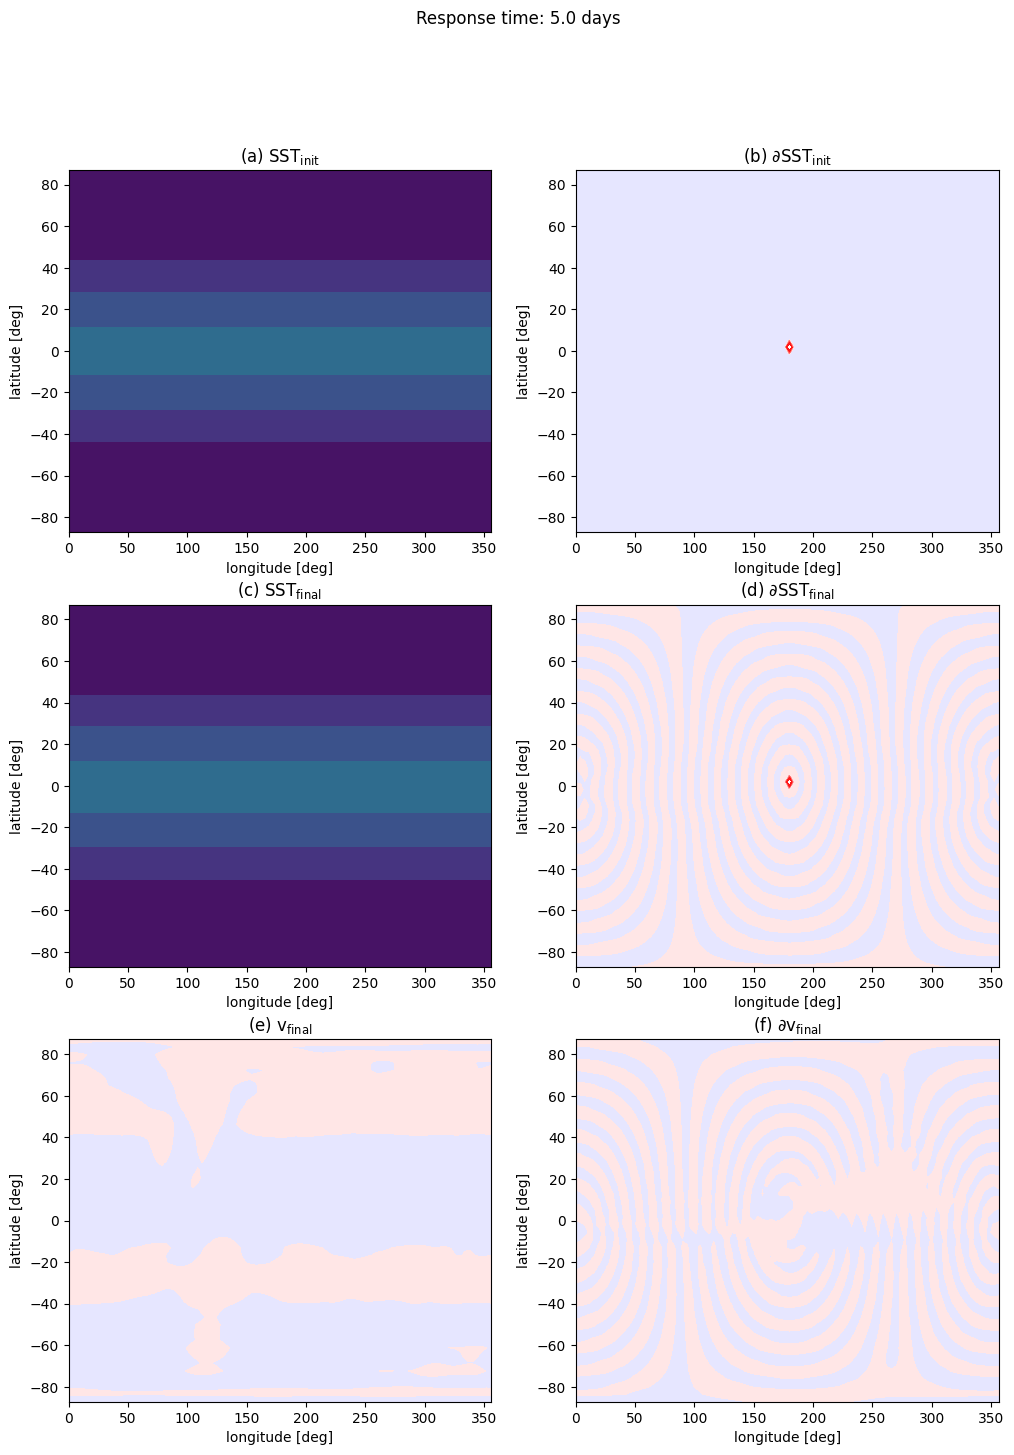

In [7]:
lat = atm_model.coords.horizontal.latitudes * 180/jnp.pi
lon = atm_model.coords.horizontal.longitudes * 180/jnp.pi

fig, ax = plt.subplots(3, 2, figsize=(12, 16))

sst_levels = jnp.linspace(-2, 35, 11)
tangent_sst_levels = jnp.linspace(-1, 1, 11) * 0.5
v_levels = jnp.linspace(-1, 1, 11) * 5
tangent_v_levels = jnp.linspace(-1, 1, 11) * 0.2

ax[0, 0].contourf(lon, lat, (sst_initial-273.15).transpose(), levels=sst_levels)
ax[0, 1].contourf(lon, lat, tangent_sst_initial.transpose(), levels=tangent_sst_levels, cmap="bwr")
ax[1, 0].contourf(lon, lat, (sst_final-273.15).transpose(), levels=sst_levels)
ax[1, 1].contourf(lon, lat, tangent_sst_final.transpose(), levels=tangent_sst_levels, cmap="bwr")
ax[2, 0].contourf(lon, lat, v_final.transpose(), levels=v_levels, cmap="bwr")
ax[2, 1].contourf(lon, lat, tangent_v_final.transpose(), levels=tangent_v_levels, cmap="bwr")

ax[0, 0].set_title("(a) $\\mathrm{SST}_\\mathrm{init}$")
ax[0, 1].set_title("(b) $\\partial \\mathrm{SST}_\\mathrm{init}$")
ax[1, 0].set_title("(c) $\\mathrm{SST}_\\mathrm{final}$")
ax[1, 1].set_title("(d) $\\partial \\mathrm{SST}_\\mathrm{final}$")
ax[2, 0].set_title("(e) $\\mathrm{v}_\\mathrm{final}$")
ax[2, 1].set_title("(f) $\\partial \\mathrm{v}_\\mathrm{final}$")

fig.suptitle(f"Response time: {simulation_interval / jdt.to_timedelta(1, 'day'):.1f} days")
for _ax in ax.flatten():
    _ax.set_xlabel("longitude [deg]")
    _ax.set_ylabel("latitude [deg]")
    
print(f"Saving result figures into: {output_figure}")
plt.savefig(output_figure, dpi=200)

if use_ipython:
    plt.show()